In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from load_data import load_movies
from preprocessing import preprocess

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC, SVC, NuSVC
from sklearn.ensemble import RandomForestClassifier

from nltk.corpus import stopwords
stopwords_en = list(stopwords.words('english'))

data_path = "../datasets/"
path = data_path + "movies1000/"
alltxts, y = load_movies(path)

RANDOM_STATE = 42
N_SPLIT = 5

alltxts = preprocess(texts=alltxts)
X = TfidfVectorizer(stop_words=stopwords_en, min_df=0.005, ngram_range=(1, 2), sublinear_tf=True, strip_accents=None, lowercase=False, preprocessor=None)
X = X.fit_transform(alltxts)

clf = LinearSVC(random_state=RANDOM_STATE)#.fit(X_train, y_train)
# pred = clf.predict(X_test)

# Calcul des performances du modèle
scoring = ['accuracy', 'f1', 'precision', 'recall']
cv_strategy = KFold(n_splits=N_SPLIT, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(clf, X, y, cv=cv_strategy, scoring=scoring, n_jobs=-1)

# --- Affichage des résultats ---
print(f"Résultats sur {N_SPLIT}-Fold Cross-Validation :")
print("-" * 40)
print(f"| Accuracy | {cv_results['test_accuracy'].mean():.3%} (+/- {cv_results['test_accuracy'].std():.3%}) |")
print(f"| F1-score | {cv_results['test_f1'].mean():.3%} (+/- {cv_results['test_f1'].std():.3%}) |")
print(f"| Précision | {cv_results['test_precision'].mean():.3%} (+/- {cv_results['test_precision'].std():.3%}) |")
print(f"| Rappel | {cv_results['test_recall'].mean():.3%} (+/- {cv_results['test_recall'].std():.3%}) |")


# alltxts = preprocess(texts=alltxts)
# X = TfidfVectorizer(sublinear_tf=True).fit_transform(alltxts)


# clf = LinearSVC(random_state=RANDOM_STATE)#.fit(X_train, y_train)
# # pred = clf.predict(X_test)

# # Calcul des performances du modèle
# scoring = ['accuracy', 'f1', 'roc_auc']
# cv_strategy = KFold(n_splits=N_SPLIT, shuffle=True, random_state=RANDOM_STATE)
# cv_results = cross_validate(clf, X, y, cv=cv_strategy, scoring=scoring, n_jobs=-1)
# # return_train_score=True,
# # --- Affichage des résultats ---
# # print(f"Résultats sur {N_SPLIT}-Fold Cross-Validation :")
# # print("-" * 40)
# # print(f"| Accuracy | {cv_results['train_accuracy'].mean():.3%} (+/- {cv_results['train_accuracy'].std():.3%}) |")
# # print(f"| F1-score | {cv_results['train_f1'].mean():.3%} (+/- {cv_results['train_f1'].std():.3%}) |")
# # print(f"| ROC AUC  | {cv_results['train_roc_auc'].mean():.3%} (+/- {cv_results['train_roc_auc'].std():.3%}) |")
# # print("\n")
# print(f"Résultats sur {N_SPLIT}-Fold Cross-Validation :")
# print("-" * 40)
# print(f"| Accuracy | {cv_results['test_accuracy'].mean():.3%} (+/- {cv_results['test_accuracy'].std():.3%}) |")
# print(f"| F1-score | {cv_results['test_f1'].mean():.3%} (+/- {cv_results['test_f1'].std():.3%}) |")
# print(f"| ROC AUC  | {cv_results['test_roc_auc'].mean():.3%} (+/- {cv_results['test_roc_auc'].std():.3%}) |")


Résultats sur 5-Fold Cross-Validation :
----------------------------------------
| Accuracy | 87.750% (+/- 1.151%) |
| F1-score | 87.803% (+/- 1.009%) |
| Précision | 87.524% (+/- 2.080%) |
| Rappel | 88.118% (+/- 0.863%) |


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from load_data import load_movies
from nltk.corpus import stopwords

stopwords_en = list(stopwords.words('english'))

data_path = "../datasets/"
path = data_path + "movies1000/"
alltxts, y = load_movies(path)

RANDOM_STATE = 42
N_SPLIT = 5

# alltxt = preprocess(texts=alltxts)

# --- Pipeline TF-IDF + LinearSVC ---
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf',   LinearSVC(random_state=RANDOM_STATE)),
])

# --- Grille de paramètres à tester ---
param_grid = {
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'tfidf__max_df':       [.75, 0.85, 0.95, 1.0],
    'tfidf__min_df':       [1, 2, 3, 5],

    #'tfidf__max_features': [None, 37_000],

    #'tfidf__smooth_idf':   [True, False],
    #'tfidf__use_idf':      [True, False], 
    #'tfidf__sublinear_tf': [True, False],

    #'tfidf__norm':         ['l2', 'l1', None],

    #'tfidf__analyzer':     ['word', 'char_wb'],

    "tfidf__stop_words": [None, stopwords_en],
}
# --- GridSearchCV (validation interne) ---
cv_strategy = KFold(n_splits=N_SPLIT, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv_strategy,
    scoring='f1',          # métrique pilote pour choisir le meilleur modèle
    n_jobs=-1,
    verbose=1,
    refit=True,            # réentraîne sur tout X avec les meilleurs params
)

grid_search.fit(alltxts, y)

# --- Meilleurs paramètres ---
print("Meilleurs paramètres :")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"  → Meilleur F1 (CV interne) : {grid_search.best_score_:.3%}")

# --- Évaluation complète avec cross_validate sur le meilleur pipeline ---
scoring = ['accuracy', 'f1', 'roc_auc']

cv_results = cross_validate(
    grid_search.best_estimator_,
    alltxts, y,
    cv=cv_strategy,
    scoring=scoring,
    n_jobs=-1,
)
print(f"\nRésultats sur {N_SPLIT}-Fold Cross-Validation (meilleurs params) :")
print("-" * 40)
print(f"| Accuracy | {cv_results['test_accuracy'].mean():.3%} (+/- {cv_results['test_accuracy'].std():.3%}) |")
print(f"| F1-score | {cv_results['test_f1'].mean():.3%}     (+/- {cv_results['test_f1'].std():.3%}) |")

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Meilleurs paramètres :
  tfidf__smooth_idf: True
  → Meilleur F1 (CV interne) : 88.633%

Résultats sur 5-Fold Cross-Validation (meilleurs params) :
----------------------------------------
| Accuracy | 88.600% (+/- 1.091%) |
| F1-score | 88.633%     (+/- 1.198%) |


In [79]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from load_data import load_pres
from nltk.corpus import stopwords

stopwords_fr = list(stopwords.words('french'))

data_path = "../datasets/"
fname = data_path + "corpus.tache1.learn.utf8"
alltxts, y = load_pres(fname)

RANDOM_STATE = 44
N_SPLIT = 10

# alltxt = preprocess(texts=alltxts)

# --- Pipeline TF-IDF + LinearSVC ---
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf',   LinearSVC(random_state=RANDOM_STATE)),
])

# --- Grille de paramètres à tester ---
param_grid = {
    'tfidf__ngram_range':  [(1, 2)],
    # 'tfidf__max_df':       [0.85, 0.95, 1.0],
    # 'tfidf__min_df':       [1, 2, 3],

    #'tfidf__max_features': [None, 37_000],

    'tfidf__smooth_idf':   [False],
    #'tfidf__use_idf':      [True, False], 
    'tfidf__sublinear_tf': [True],

    #'tfidf__norm':         ['l2', 'l1', None],

    #'tfidf__analyzer':     ['word', 'char_wb'],

    # "tfidf__stop_words": [None, stopwords_fr],
    'clf__C': [1, 0.9, 0.95],
}
# --- GridSearchCV (validation interne) ---
cv_strategy = StratifiedKFold(n_splits=N_SPLIT, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv_strategy,
    scoring='f1',          # métrique pilote pour choisir le meilleur modèle
    n_jobs=-1,
    verbose=1,
    refit=True,            # réentraîne sur tout X avec les meilleurs params
)

grid_search.fit(alltxts, y)

# --- Meilleurs paramètres ---
print("Meilleurs paramètres :")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"  → Meilleur F1 (CV interne) : {grid_search.best_score_:.3%}")

scoring = ['f1', 'roc_auc', 'average_precision']

cv_results = cross_validate(
    grid_search.best_estimator_,
    alltxts, y,
    cv=cv_strategy,
    scoring=scoring,
    n_jobs=-1,
)

print(f"Résultats sur {N_SPLIT}-Fold Cross-Validation :")
print("-" * 40)
print(f"| F1-score | {cv_results['test_f1'].mean():.3%} (+/- {cv_results['test_f1'].std():.3%}) |")
print(f"| ROC AUC  | {cv_results['test_roc_auc'].mean():.3%} (+/- {cv_results['test_roc_auc'].std():.3%}) |")
print(f"| Avg Precision | {cv_results['test_average_precision'].mean():.3%} (+/- {cv_results['test_average_precision'].std():.3%}) |")

Fitting 10 folds for each of 3 candidates, totalling 30 fits
Meilleurs paramètres :
  clf__C: 0.95
  tfidf__ngram_range: (1, 2)
  tfidf__smooth_idf: False
  tfidf__sublinear_tf: True
  → Meilleur F1 (CV interne) : 95.256%
Résultats sur 10-Fold Cross-Validation :
----------------------------------------
| F1-score | 95.256% (+/- 0.173%) |
| ROC AUC  | 90.305% (+/- 0.435%) |
| Avg Precision | 98.107% (+/- 0.109%) |


In [5]:
from gensim.models import FastText
import numpy as np

tokens = [t.lower().split() for t in alltxts]
ft = FastText(tokens, vector_size=100, window=5, min_count=2, epochs=10)

# Moyenne des vecteurs de chaque document
def doc_vector(text):
    words = text.lower().split()
    vecs = [ft.wv[w] for w in words if w in ft.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(100)

X_ft = np.array([doc_vector(t) for t in alltxts])

clf = LinearSVC(random_state=RANDOM_STATE)
cv_results = cross_validate(clf, X_ft, y, cv=cv_strategy,
                            scoring='accuracy', return_train_score=True)
print(f"Accuracy : {cv_results['test_score'].mean():.3%}")

Accuracy : 73.450%


In [ ]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

from load_data import load_movies

data_path = "../datasets/train/"
path = data_path + "movies1000/"
alltxts, y = load_movies(path)

RANDOM_STATE = 42
N_SPLIT = 5

MODEL = "distilbert-base-uncased"
MODEL = "textattack/bert-base-uncased-SST-2"
tokenizer = AutoTokenizer.from_pretrained(MODEL)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True,
                     padding=True, max_length=512)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = softmax(logits, axis=1)[:, 1]
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds),
        "precision score":   precision_score(labels, preds),
        "recall score":   recall_score(labels, preds),
    }

from scipy.special import softmax

ds = Dataset.from_dict({"text": alltxts, "label": y})
ds = ds.train_test_split(test_size=0.2, seed=42)
ds = ds.map(tokenize, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=2)

args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds["train"],
    eval_dataset=ds["test"],
    compute_metrics=compute_metrics,
)

trainer.train()

# --- Print final ---
metrics = trainer.predict(ds["test"])

preds = np.argmax(metrics.predictions, axis=1)
probs = softmax(metrics.predictions, axis=1)[:, 1]
labels = metrics.label_ids

print("\n" + "=" * 45)
print("  DistilBERT — Résultats finaux (test set)")
print("=" * 45)
print(f"  Accuracy  : {accuracy_score(labels, preds):.3%}")
print(f"  F1-score  : {f1_score(labels, preds):.3%}")
print(f"  precision_score   : {precision_score(labels, preds):.3%}")
print(f"  recall_score   : {recall_score(labels, preds):.3%}")
print(f"  Loss      : {metrics.metrics['test_loss']:.4f}")
print("=" * 45)

# President test csv


In [8]:
def gaussian_kernel(size, sigma=1.0):
    """
    Génère un noyau gaussien normalisé
    """
    x = np.arange(size) - size // 2
    kernel = np.exp(-(x**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel


def gaussian_smoothing(pred, size=5, sigma=1.0):
    """
    Applique un lissage gaussien sur les prédictions
    
    pred : liste ou array de prédictions (-1, 1)
    size : taille du filtre (impair recommandé)
    sigma : écart-type de la gaussienne
    """
    kernel = gaussian_kernel(size, sigma)
    
    # Convolution
    smoothed = np.convolve(pred, kernel, mode='same')
    
    # Reprojection en classes (-1, 1)
    return smoothed


import numpy as np
import matplotlib.pyplot as plt
from load_data import load_pres
from preprocessing import preprocess

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC, SVC
from scipy.ndimage import gaussian_filter

data_path = "../datasets/"
fname = data_path + "corpus.tache1.learn.utf8"
alltxts, y = load_pres(fname)

def con(probas):
    return [1 if p > 0.5 else 0 for p in probas]

y = np.array(con(y))

alltxts = preprocess(texts=alltxts)
X = TfidfVectorizer(ngram_range=(1, 2), strip_accents=None, lowercase=False, preprocessor=None).fit_transform(alltxts)

RANDOM_STATE = 42
N_SPLIT = 10

clf = LinearSVC(class_weight='balanced', C= 0.95, random_state=RANDOM_STATE)

# scoring = ['f1', 'roc_auc', 'average_precision']
# cv_strategy = KFold(n_splits=N_SPLIT, shuffle=True, random_state=RANDOM_STATE)
# cv_results = cross_validate(clf, X, y, cv=cv_strategy, scoring=scoring, n_jobs=-1)

kf = KFold(n_splits=N_SPLIT, shuffle=True, random_state=RANDOM_STATE)

# Stocker les métriques par fold
roc_auc, f1s, ap = [], [], []

sigma = 0.1  # valeur de sigma pour lisser les prédictions

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test_fold = y[train_index], y[test_index]
    
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    
    # Lissage gaussien sur les 0/1
    pred_lissees = gaussian_filter(pred, sigma=sigma)
    pred_final = con(pred_lissees)
    
    # Calcul des métriques
    roc_auc.append(roc_auc_score(y_test_fold, pred_final))
    f1s.append(f1_score(y_test_fold, pred_final))
    ap.append(average_precision_score(y_test_fold, pred_final))

# Affichage résumé comme cross_validate
print(f"Résultats sur {N_SPLIT}-Fold Cross-Validation :")
print("-" * 50)
print(f"| roc_auc_score | {np.mean(roc_auc):.3%} (+/- {np.std(roc_auc):.3%}) |")
print(f"| F1-score | {np.mean(f1s):.3%} (+/- {np.std(f1s):.3%}) |")
print(f"| ap | {np.mean(ap):.3%} (+/- {np.std(ap):.3%}) |")

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, train_size=0.8, random_state=RANDOM_STATE, shuffle=False
# )

# clf.fit(X_train, y_train)


# probas = clf.predict(X_test)

# y_test = con(y_test)
# probas = con(probas)



# # import pandas as pd
# # df = pd.DataFrame({"Pres": probas_lissees})
# # df.to_csv("csv/submission.csv", index=False)


# for sigma in np.linspace(0.1, 2, 20):
#     print(sigma)
#     probas_lissees = gaussian_smoothing(probas, sigma=sigma)

#     print(f"| Accuracy | {accuracy_score(probas, y_test):.3%}")
#     print(f"| Accuracy | {accuracy_score(con(probas_lissees), y_test):.3%}")


#     nb_graph_phrase = 500


#     plt.figure()
#     plt.plot(list(range(len(y_test[0:nb_graph_phrase]))), probas[0:nb_graph_phrase])
#     plt.plot(list(range(len(y_test[0:nb_graph_phrase]))), y_test[0:nb_graph_phrase])
#     plt.xlabel("Phrases")
#     plt.ylabel("Locuteur")
#     plt.show()

#     plt.figure()
#     plt.plot(list(range(len(y_test[0:nb_graph_phrase]))), probas_lissees[0:nb_graph_phrase])
#     plt.xlabel("Phrases")
#     plt.ylabel("Locuteur")
#     plt.show()

Résultats sur 10-Fold Cross-Validation :
--------------------------------------------------
| roc_auc_score | 75.426% (+/- 0.964%) |
| F1-score | 94.803% (+/- 0.237%) |
| ap | 93.118% (+/- 0.325%) |


Résultats sur 10-Fold Cross-Validation avec lissage gaussien sigma=0.2:
------------------------------------------------------------
| ROC AUC        | 89.709% (+/- 0.547%) |
| F1-score       | 86.889% (+/- 0.378%) |
| Avg Precision  | 98.020% (+/- 0.210%) |


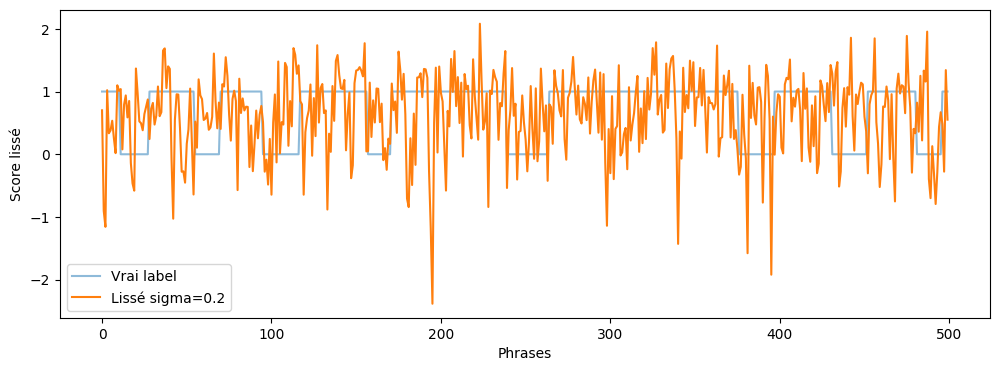

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from load_data import load_pres
from preprocessing import preprocess

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score
from scipy.ndimage import gaussian_filter


# --- Chargement et prétraitement des données ---
data_path = "../datasets/"
fname = data_path + "corpus.tache1.learn.utf8"
alltxts, y = load_pres(fname)
alltxts = preprocess(texts=alltxts)
def binarize(pred, seuil=0.5):
    """Convertit les scores lissés en 0/1 pour F1-score et Accuracy"""
    return [1 if p > seuil else 0 for p in pred]
y = np.array(binarize(y))  # nécessaire pour indexation KFold

X = TfidfVectorizer(ngram_range=(1,2), lowercase=False).fit_transform(alltxts)

# --- Paramètres ---
RANDOM_STATE = 42
N_SPLIT = 10
sigma = 0.2  # lissage gaussien léger
kf = KFold(n_splits=N_SPLIT, shuffle=True, random_state=RANDOM_STATE)
clf = LinearSVC(class_weight='balanced', C=0.95, random_state=RANDOM_STATE)

# --- Stockage des métriques par fold ---
roc_auc_list, f1_list, ap_list = [], [], []


# --- Boucle K-Fold ---
for train_idx, test_idx in kf.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test_fold = y[train_idx], y[test_idx]
    
    # Entraînement
    clf.fit(X_train, y_train)
    
    # Scores continus (distance à l'hyperplan)
    scores = clf.decision_function(X_test)
    
    # Lissage gaussien sur les scores continus
    scores_lissees = gaussian_filter(scores, sigma=sigma)
    
    # Métriques
    roc_auc_list.append(roc_auc_score(y_test_fold, scores_lissees))
    ap_list.append(average_precision_score(y_test_fold, scores_lissees))
    
    # F1-score et Accuracy nécessitent des classes binaires
    pred_classes = binarize(scores_lissees)
    f1_list.append(f1_score(y_test_fold, pred_classes))

# --- Affichage résumé comme cross_validate ---
print(f"Résultats sur {N_SPLIT}-Fold Cross-Validation avec lissage gaussien sigma={sigma}:")
print("-" * 60)
print(f"| ROC AUC        | {np.mean(roc_auc_list):.3%} (+/- {np.std(roc_auc_list):.3%}) |")
print(f"| F1-score       | {np.mean(f1_list):.3%} (+/- {np.std(f1_list):.3%}) |")
print(f"| Avg Precision  | {np.mean(ap_list):.3%} (+/- {np.std(ap_list):.3%}) |")

# --- Visualisation (optionnelle) ---
nb_graph_phrase = 500
plt.figure(figsize=(12,4))
plt.plot(y[:nb_graph_phrase], alpha=0.5, label="Vrai label")
plt.plot(scores_lissees[:nb_graph_phrase], label=f"Lissé sigma={sigma}")
plt.xlabel("Phrases")
plt.ylabel("Score lissé")
plt.legend()
plt.show()


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from load_data import load_pres, load_pres_test
from preprocessing import preprocess

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression


data_path = "../datasets/"
fname = data_path + "corpus.tache1.learn.utf8"
alltxts, y = load_pres(fname)
alltxts_test = load_pres_test("../datasets_test_projet/corpus.tache1.test.utf8")

alltxts = preprocess(texts=alltxts)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), strip_accents=None, lowercase=False, preprocessor=None)
X = vectorizer.fit_transform(alltxts)

alltxts_test = preprocess(texts=alltxts_test)
X_test = vectorizer.transform(alltxts_test)

RANDOM_STATE = 42
N_SPLIT = 10


clf = LinearSVC(class_weight='balanced', C= 0.95, random_state=RANDOM_STATE).fit(X, y)
pred = clf.predict(X_test)
#condition, resultat_if, resultat_else
arr = np.where(pred == -1, 0.9, 0.1)

In [33]:
data_path = "../datasets/"
fname = data_path + "corpus.tache1.learn.utf8"
alltxts, y = load_pres(fname)

RANDOM_STATE = 42
N_SPLIT = 5

alltxts = preprocess(texts=alltxts)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), strip_accents=None, lowercase=False, preprocessor=None)
X = vectorizer.fit_transform(alltxts)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=RANDOM_STATE
)


clf = LinearSVC(class_weight='balanced', C= 0.95, random_state=RANDOM_STATE).fit(X_train, y_train)
pred = clf.predict(X_test)

average_precision = average_precision_score(y_test, pred)
f1_score_ = f1_score(y_test, pred)
auc = roc_auc_score(y_test, pred)

print(f"f1_score = {f1_score_:.3%}")
print(f"{auc = :.3%}")
print(f"{average_precision = :.3%}")

f1_score = 94.844%
auc = 75.059%
average_precision = 93.138%


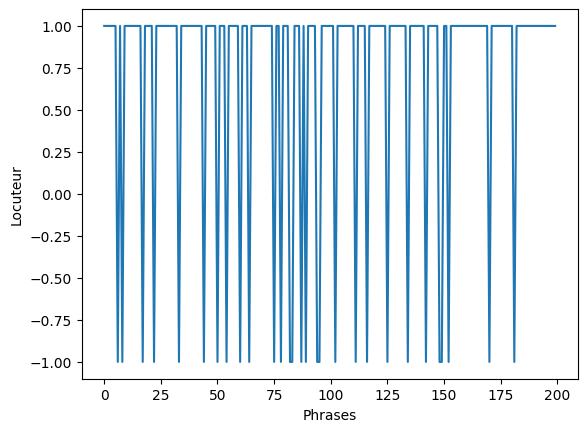

[1, 1, 1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, -1, 1, 1, 1, -1, -1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, 1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, 1,

ValueError: unknown format is not supported

In [ ]:
### Graph de post-praitement
from scipy.ndimage import gaussian_filter

nb_graph_phrase = 200


plt.figure()
plt.plot(list(range(len(y_test[0:nb_graph_phrase]))), y_test[0:nb_graph_phrase])
plt.xlabel("Phrases")
plt.ylabel("Locuteur")
plt.show()

#condition, resultat_if, resultat_else

mitt = 0.9
chirac = 0.1
arr = np.where(pred == -1, mitt, chirac)
y_arr = np.where(y_test == -1, mitt, chirac)


def gaussian_to_pred(arr):
    return np.where(arr > 0.5, 0.9, 0.1)

arr_pred = gaussian_to_pred(y_arr)

print(y_test, arr_pred)
average_precision = average_precision_score(y_arr, arr_pred)
f1_score_ = f1_score(y_arr, arr_pred)
auc = roc_auc_score(y_arr, arr_pred)

plt.figure()
plt.plot(list(range(len(y_test[0:nb_graph_phrase]))), arr[0:nb_graph_phrase])
plt.xlabel("Phrases")
plt.ylabel("Locuteur")
plt.show()

plt.figure()
plt.plot(list(range(len(y_test[0:nb_graph_phrase]))), gaussian_filter(arr[0:nb_graph_phrase], sigma=1.25))
plt.xlabel("Phrases")
plt.ylabel("Locuteur")
plt.show()

f1_score = 92.600%
auc = 78.208%
average_precision = 93.994%
f1_score = 93.078%
auc = 51.294%
average_precision = 87.394%


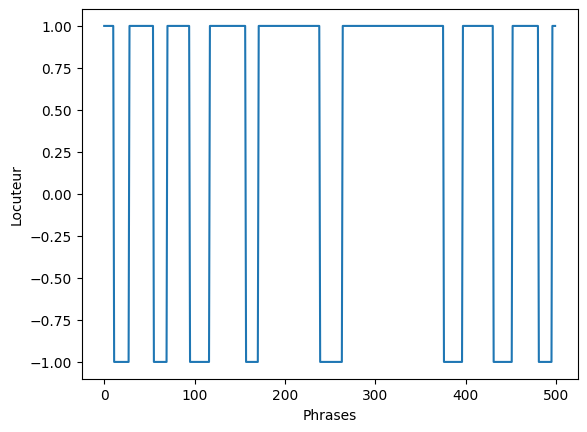

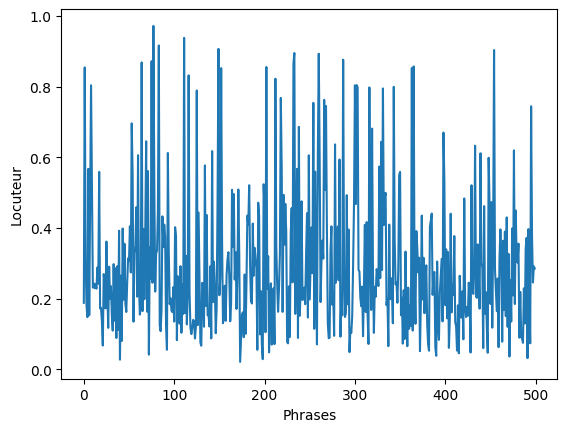

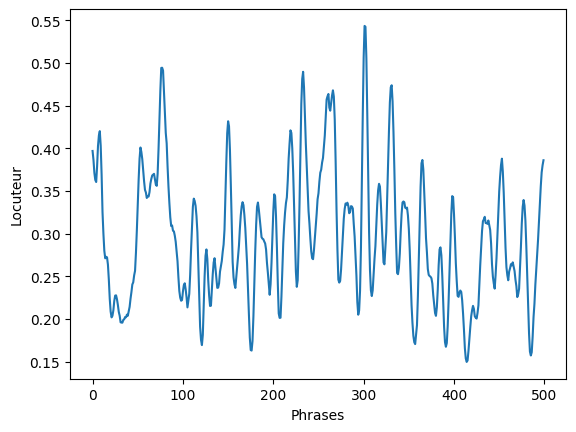

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from load_data import load_pres, load_pres_test
from preprocessing import preprocess

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression


data_path = "../datasets/"
fname = data_path + "corpus.tache1.learn.utf8"
alltxts, y = load_pres(fname)
alltxts_test = load_pres_test("../datasets_test_projet/corpus.tache1.test.utf8")

alltxts = preprocess(texts=alltxts)
vectorizer = TfidfVectorizer(ngram_range=(1, 2), strip_accents=None, lowercase=False, preprocessor=None)
X = vectorizer.fit_transform(alltxts)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=RANDOM_STATE
)

# alltxts_test = preprocess(texts=alltxts_test)
# X_test = vectorizer.transform(alltxts_test)

RANDOM_STATE = 42
N_SPLIT = 10

clf = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE).fit(X_train, y_train)
pred = clf.predict(X_test)

average_precision = average_precision_score(y_test, pred)
f1_score_ = f1_score(y_test, pred)
auc = roc_auc_score(y_test, pred)

print(f"f1_score = {f1_score_:.3%}")
print(f"{auc = :.3%}")
print(f"{average_precision = :.3%}")

prob = clf.predict_proba(X_test)
prob_Mitt, prob_Chirac = prob[:, 0], prob[:, 1]


from scipy.ndimage import gaussian_filter
sigma = 2.5
radius = 1
prob_Chirac_post = gaussian_filter(input=prob_Chirac, radius=radius, sigma=sigma)
prob_Mitt_post = gaussian_filter(input=prob_Mitt, radius=radius, sigma=sigma)


def prob2pred_Chirac(proba):
    return [1 if p > 0.5 else -1 for p in proba]

def prob2pred_Mitt(proba):
    return [-1 if p > 0.5 else 1 for p in proba]

pred_post = prob2pred_Chirac(prob_Chirac_post)
pred_post = prob2pred_Mitt(prob_Mitt_post)




average_precision = average_precision_score(y_test, pred_post)
f1_score_ = f1_score(y_test, pred_post)
auc = roc_auc_score(y_test, pred_post)

print(f"f1_score = {f1_score_:.3%}")
print(f"{auc = :.3%}")
print(f"{average_precision = :.3%}")



## Post-praitement

nb_graph_phrase = 500

plt.figure()
plt.plot(list(range(len(y[0:nb_graph_phrase]))), y[0:nb_graph_phrase])
# plt.plot(list(range(len(y[0:nb_graph_phrase]))), pred_post[0:nb_graph_phrase])
plt.xlabel("Phrases")
plt.ylabel("Locuteur")
plt.show()
    
plt.figure()
plt.plot(list(range(len(y[0:nb_graph_phrase]))), prob_Mitt[0:nb_graph_phrase])
plt.xlabel("Phrases")
plt.ylabel("Locuteur")
plt.show()

plt.figure()
plt.plot(list(range(len(y[0:nb_graph_phrase]))), prob_Mitt_post[0:nb_graph_phrase])
plt.xlabel("Phrases")
plt.ylabel("Locuteur")
plt.show()

# clf = LinearSVC(class_weight='balanced', C= 0.95, random_state=RANDOM_STATE).fit(X, y)
# pred = clf.predict(X_test)

# #condition, resultat_if, resultat_else
# arr = np.where(pred == -1, 1, 0)

# Sauvegarder le résultat dans un fichier
# import glob
# n = len(glob.glob('csv/submission-pres-*.csv')) + 1
# np.savetxt(f"csv/submission-pres-{n}.csv", arr, fmt="%s")